# Laboratorio 5 - Reto Babel
## Aplicación de Atención y Transformers

**Modalidad:** grupos de hasta 3 integrantes  
**Entrega:** domingo 6 de septiembre de 2026, 23:59  
**Archivo:** `S09_Lab05_Reto_Babel_ESTUDIANTE.ipynb`  
**Valor:** 100 puntos

Su misión es entrenar un traductor de un idioma inventado al español utilizando PyTorch.

El diccionario ayuda a reconocer las palabras, pero el modelo debe aprender a reorganizarlas. En el
idioma secreto el verbo aparece al final, el adjetivo antes del sustantivo y la negación después del verbo.

### Reglas

- Use únicamente PyTorch y la biblioteca estándar de Python. No use NumPy.
- Use `nn.Transformer`; no reimplemente internamente la atención multi-cabeza.
- No use modelos preentrenados, traductores externos ni APIs generativas.
- No modifique las celdas de verificación.
- Entregue el notebook ejecutado, con las respuestas y salidas visibles.

## Bloque 0 - Investigación guiada (20 puntos)

Lea las secciones 1, 3.1, 3.2 y 3.5 de [*Attention Is All You Need*](https://arxiv.org/abs/1706.03762)
y consulte la [documentación de `nn.Transformer`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Transformer.html).

Responda con lenguaje sencillo y cite el enlace utilizado. Estas son las **únicas cuatro preguntas de
investigación** del laboratorio:

1. ¿Qué limitación de los modelos recurrentes buscaba resolver el Transformer y por qué la traducción era una tarea importante para demostrarlo?
2. ¿Qué trabajo realizan el encoder, la self-attention enmascarada del decoder y la atención entre decoder y encoder en un traductor?
3. ¿Por qué el Transformer necesita información posicional y qué espera que ocurra en este laboratorio si se elimina?
4. ¿Qué ventaja y qué costo de la atención frente a la recurrencia identifica en el artículo, y cómo se relacionan con las frases cortas del Reto Babel?

### Respuestas del grupo

**1.**  
La limitación de los modelos recurrentes que buscaba resolver el Transformer era la incapacidad de entrenarse en paralelo, ya que los modelos recurrentes requieren de la salida anterior para entrenar la siguiente.  La traducción era la tarea donde dominaban los modelos recurrentes y exige tener en cuenta la secuencia de palabras, la cual se quería paralelizar.

**Fuente:**  
*This inherently sequential nature precludes parallelization within training examples, which becomes critical at longer sequence lengths, as memory constraints limit batching across examples* (Vaswani et al., 2017).  
*Recurrent neural networks, long short-term memory and gated recurrent neural networks in particular, have been firmly established as state of the art approaches in sequence modeling and transduction problems such as language modeling and machine translation* (Vaswani et al., 2017).  


**2.**  
**encoder:** Recibe la entrada original y genera representaciones con el contexto de todas sus palabras mediante self-attention.  
**self-attention enmascarada del decoder:** Analiza las palabras de la traducción conocidas, evitando pasar las palabras futuras que debe predecir.  
**atención entre el decoder y encoder:** Permite que el decoder consulte información producida por el encoder, identificando qué partes de la oración original son relevantes al generar cada palabra de la traducción.  

**Fuente:**  
*In a self-attention layer all of the keys, values and queries come from the same place, in this case, the output of the previous layer in the encoder. Each position in the encoder can attend to all positions in the previous layer of the encoder.* (Vaswani et al., 2017)  
*in the decoder allow each position in the decoder to attend to all positions in the decoder up to and including that position. We need to prevent leftward information flow in the decoder to preserve the auto-regressive property. We implement this inside of scaled dot-product attention by masking out (setting to −∞) all values in the input of the softmax which correspond to illegal connections.* (Vaswani et al., 2017)  
*the queries come from the previous decoder layer, and the memory keys and values come from the output of the encoder. This allows every position in the decoder to attend over all positions in the input sequence.* (Vaswani et al., 2017)

**3.**  
El Transformer usa información posicional para que el modelo sea capaz de hacer uso del orden de la sucesión, ya que tiene convolución ni recurrencia. Si se elimina afectará el entrenamiento del modelo, ya que le costará mucho más el orden de las palabras, haciendo que disminuya la capacidad predictiva del modelo.  
**Fuente:** *Since our model contains no recurrence and no convolution, in order for the model to make use of the order of the sequence, we must inject some information about the relative or absolute position of the tokens in the sequence. To this end, we add "positional encodings" to the input embeddings at the bottoms of the encoder and decoder stacks.* (Vaswani et al., 2017)

**4.**  
La ventaja de la atención frente a la recurrencia es principalmente su rapidez por la parelelización, en particular cuando la longitud de la sucesión es menor que su dimensión.  
El costo con el que la self-attention compara las posiciones entre sí para una secuencia de longitud $n$ y dimensión $d$, su complejidad por capa es $O(n^2d)$, mientras que una capa recurrente es de $O(nd^2)$. Esto hace que atención se vuelva cara con cadenas largas, mientras que las recurrentes son más caras al aumentar las dimensiones.  
Esto queda bien con las frases cortas del Reto de Babel, ya que atención no recibe cadenas largas, haciendo que sea más rápida de entrenar.

**Fuente:**  
*In terms of computational complexity, self-attention layers are faster than recurrent layers when the sequence length n is smaller than the representation dimensionality d, which is most often the case with sentence representations used by state-of-the-art models in machine translations, such as word-piece[38] and byte-pair [31] representations.* (Vaswani et al., 2017)  
*Tabla 1*.(Vaswani et al., 2017)  

## Bloque 1 - Preparar el entorno y explorar los datos (5 puntos)

Cargue los tres CSV recibidos. Verifique cuántos ejemplos tiene y observe cómo cambia el orden entre
el idioma secreto y el español. El diccionario es una ayuda; el modelo debe aprender la transformación.

In [1]:
from __future__ import annotations

import csv
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

SEMILLA = 42
random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DISPOSITIVO)

# Ejemplos de funciones utilizadas en este bloque:
# torch.manual_seed(...), torch.device(...), torch.cuda.is_available()

Dispositivo: cpu


In [2]:
# Descomprima el ZIP recibido y escriba aquí la carpeta que contiene los tres CSV.
CARPETA_DATOS = Path("G2_Reto_Babel")

# Ejemplos de funciones utilizadas en este bloque:
# Path("carpeta"), Path.exists(), Path / "archivo.csv"
assert CARPETA_DATOS.exists(), "Actualice CARPETA_DATOS con la carpeta recibida."

In [3]:
def leer_pares(ruta: Path):
    with ruta.open(encoding="utf-8", newline="") as archivo:
        return list(csv.DictReader(archivo))


class Vocabulario:
    ESPECIALES = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]

    def __init__(self, tokens):
        unicos = self.ESPECIALES + sorted(set(tokens) - set(self.ESPECIALES))
        self.token_a_id = {token: i for i, token in enumerate(unicos)}
        self.id_a_token = {i: token for token, i in self.token_a_id.items()}

    def __len__(self):
        return len(self.token_a_id)

    def codificar(self, texto, agregar_inicio_fin=True):
        ids = [self.token_a_id.get(token, self.token_a_id["<UNK>"]) for token in texto.split()]
        if agregar_inicio_fin:
            ids = [self.token_a_id["<SOS>"]] + ids + [self.token_a_id["<EOS>"]]
        return ids

    def decodificar(self, ids):
        tokens = []
        for indice in ids:
            token = self.id_a_token[int(indice)]
            if token == "<EOS>":
                break
            if token not in {"<PAD>", "<SOS>"}:
                tokens.append(token)
        return " ".join(tokens)


class ParesTraduccion(Dataset):
    def __init__(self, pares, vocab_src, vocab_tgt):
        self.pares = pares
        self.vocab_src = vocab_src
        self.vocab_tgt = vocab_tgt

    def __len__(self):
        return len(self.pares)

    def __getitem__(self, indice):
        fila = self.pares[indice]
        src = torch.tensor(self.vocab_src.codificar(fila["idioma_secreto"]), dtype=torch.long)
        tgt = torch.tensor(self.vocab_tgt.codificar(fila["espanol"]), dtype=torch.long)
        return src, tgt

In [4]:
pares_entrenamiento = leer_pares(CARPETA_DATOS / "entrenamiento.csv")
pares_validacion = leer_pares(CARPETA_DATOS / "validacion.csv")
diccionario = leer_pares(CARPETA_DATOS / "diccionario.csv")

tokens_src = [token for fila in pares_entrenamiento for token in fila["idioma_secreto"].split()]
tokens_tgt = [token for fila in pares_entrenamiento for token in fila["espanol"].split()]
vocab_src = Vocabulario(tokens_src)
vocab_tgt = Vocabulario(tokens_tgt)

print("Diccionario:", len(diccionario), "palabras")
print("Entrenamiento:", len(pares_entrenamiento), "frases")
print("Validación:", len(pares_validacion), "frases")
print("Ejemplo:", pares_entrenamiento[0])

assert len(diccionario) >= 20
assert len(pares_entrenamiento) >= 1000
assert {"<PAD>", "<SOS>", "<EOS>"}.issubset(vocab_tgt.token_a_id)
print("OK - datos y vocabularios cargados")

# Ejemplos de funciones utilizadas en este bloque:
# leer_pares(...), str.split(), Vocabulario(...), len(...)

Diccionario: 22 palabras
Entrenamiento: 1200 frases
Validación: 240 frases
Ejemplo: {'idioma_secreto': 'ribi tore ribi vife zoli giki zova', 'espanol': 'el jardinero no lleva el perro joven'}
OK - datos y vocabularios cargados


## Bloque 2 - Lotes, padding y máscaras (15 puntos)

Prepare lotes de largo variable. La máscara de padding evita que el Transformer trate `<PAD>` como
una palabra real. La máscara causal evita que el decoder observe palabras futuras.

In [5]:
def crear_collate(pad_src, pad_tgt):
    def collate(lote):
        # TODO: separe srcs y tgts; aplique padding y retorne ambos tensores.
        # Ejemplos de funciones que puede utilizar:
        # zip(*lote), pad_sequence(..., batch_first=True, padding_value=...)
        srcs, tgts = zip(*lote)
        srcs = pad_sequence(srcs, batch_first=True, padding_value=pad_src)
        tgts = pad_sequence(tgts, batch_first=True, padding_value=pad_tgt)
        return  srcs, tgts
    return collate


def crear_mascara_causal(tamano, device):
    # TODO: retorne True arriba de la diagonal para ocultar palabras futuras.
    # Ejemplos de funciones que puede utilizar:
    # torch.ones(..., dtype=torch.bool, device=device), torch.triu(..., diagonal=1)
    return torch.triu(torch.ones((tamano, tamano), dtype=torch.bool, device=device), diagonal=1)



def crear_mascara_padding(tokens, pad_idx):
    # TODO: retorne True donde aparezca el token <PAD>.
    # Ejemplo de función que puede utilizar: tokens.eq(pad_idx)
    return tokens.eq(pad_idx)


In [6]:
PAD_SRC = vocab_src.token_a_id["<PAD>"]
PAD_TGT = vocab_tgt.token_a_id["<PAD>"]
collate_fn = crear_collate(PAD_SRC, PAD_TGT)

ds_entrenamiento = ParesTraduccion(pares_entrenamiento, vocab_src, vocab_tgt)
ds_validacion = ParesTraduccion(pares_validacion, vocab_src, vocab_tgt)
dl_entrenamiento = DataLoader(ds_entrenamiento, batch_size=64, shuffle=True, collate_fn=collate_fn)
dl_validacion = DataLoader(ds_validacion, batch_size=128, shuffle=False, collate_fn=collate_fn)

src_prueba, tgt_prueba = next(iter(dl_entrenamiento))
mascara = crear_mascara_causal(tgt_prueba.size(1) - 1, torch.device("cpu"))

assert src_prueba.ndim == 2 and tgt_prueba.ndim == 2
assert mascara.shape == (tgt_prueba.size(1) - 1, tgt_prueba.size(1) - 1)
assert mascara.dtype == torch.bool
assert not mascara.diag().any() and mascara[0, -1]
assert crear_mascara_padding(src_prueba, PAD_SRC).shape == src_prueba.shape
print("OK - lotes y máscaras correctos", src_prueba.shape, tgt_prueba.shape)

# Ejemplos de funciones utilizadas en este bloque:
# DataLoader(...), next(iter(...)), Tensor.size(...), torch.device(...)

OK - lotes y máscaras correctos torch.Size([64, 9]) torch.Size([64, 9])


## Bloque 3 - Configurar el traductor con `nn.Transformer` (25 puntos)

No construya la atención internamente. Ensamble embeddings, posición, `nn.Transformer` y la capa que
predice la siguiente palabra española.

In [7]:
class CodificacionPosicional(nn.Module):
    """Codificación sinusoidal del artículo original, ya implementada."""

    def __init__(self, d_modelo, max_largo=64, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        posicion = torch.arange(max_largo, dtype=torch.float32).unsqueeze(1)
        divisor = torch.exp(
            torch.arange(0, d_modelo, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_modelo)
        )
        pe = torch.zeros(1, max_largo, d_modelo)
        pe[0, :, 0::2] = torch.sin(posicion * divisor)
        pe[0, :, 1::2] = torch.cos(posicion * divisor)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

In [8]:
class TraductorTransformer(nn.Module):
    def __init__(self, n_src, n_tgt, pad_src, pad_tgt, d_modelo=48, cabezas=4,
                 capas=2, d_ff=96, dropout=0.1, usar_posicion=True):
        super().__init__()
        self.d_modelo = d_modelo
        self.pad_src = pad_src
        self.pad_tgt = pad_tgt
        self.usar_posicion = usar_posicion

        # TODO: cree dos embeddings, la posición, nn.Transformer y la capa de salida.
        # Ejemplos de funciones que puede utilizar:
        # nn.Embedding(..., padding_idx=...), CodificacionPosicional(...)
        # nn.Transformer(..., batch_first=True), nn.Linear(...)
        self.embedding_src= nn.Embedding(n_src, d_modelo, padding_idx=pad_src)
        self.embedding_tgt=nn.Embedding(n_tgt,d_modelo, padding_idx=pad_tgt)
        if usar_posicion:
            self.posicion = CodificacionPosicional(d_modelo)

        self.transformer = nn.Transformer(
            d_model=d_modelo,
            nhead=cabezas,
            num_encoder_layers=capas,
            num_decoder_layers=capas,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True
        )
        self.salida = nn.Linear(
            d_modelo,
            n_tgt
        )

    def forward(self, src, tgt_entrada):
        # TODO: convierta índices a embeddings y escale por sqrt(d_modelo).
        # TODO: agregue posición cuando self.usar_posicion sea True.
        # TODO: cree las máscaras y llame self.transformer(...).
        # TODO: convierta los estados ocultos a logits con self.salida(...).
        # Ejemplos de funciones que puede utilizar:
        # math.sqrt(...), Tensor.size(...), crear_mascara_causal(...)
        # crear_mascara_padding(...), self.transformer(...)
        
        #Embedding
        src_emb=self.embedding_src(src)*math.sqrt(self.d_modelo)
        tgt_emb=(self.embedding_tgt(tgt_entrada)*math.sqrt(self.d_modelo))

        #posicion
        if self.usar_posicion:
            src_emb = self.posicion(src_emb)
            tgt_emb = self.posicion(tgt_emb)
        if self.usar_posicion:
            src_emb = self.posicion(src_emb)
            tgt_emb = self.posicion(tgt_emb)

        #padding mask
        src_padding_mask=crear_mascara_padding(src, self.pad_src)
        tgt_padding_mask=crear_mascara_padding(tgt_entrada, self.pad_tgt)

        #mask decoder
        tgt_mask=crear_mascara_causal(tgt_entrada.size(1), tgt_entrada.device)
        
        #Transformer
        estados= self.transformer(
            src=src_emb,
            tgt=tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask)
        logits=self.salida(estados)
        return logits

In [9]:
modelo_prueba = TraductorTransformer(
    len(vocab_src), len(vocab_tgt), PAD_SRC, PAD_TGT, dropout=0.0
)
logits_prueba = modelo_prueba(src_prueba[:3], tgt_prueba[:3, :-1])

assert logits_prueba.shape == (3, tgt_prueba.size(1) - 1, len(vocab_tgt))
assert sum(p.numel() for p in modelo_prueba.parameters()) < 250_000
print("OK - modelo conectado; parámetros:", sum(p.numel() for p in modelo_prueba.parameters()))

# Ejemplos de funciones utilizadas en este bloque:
# TraductorTransformer(...), Tensor.numel(), model.parameters()

OK - modelo conectado; parámetros: 98810


## Bloque 4 - Entrenamiento (15 puntos)

Entrene con *teacher forcing*: el decoder recibe la oración española sin el último token y predice
la misma oración desplazada, sin el primer token.

In [10]:
def ejecutar_epoca(modelo, loader, criterio, optimizador=None):
    entrenando = optimizador is not None
    modelo.train(entrenando)
    total_perdida = 0.0
    total_tokens = 0

    for src, tgt in loader:
        src, tgt = src.to(DISPOSITIVO), tgt.to(DISPOSITIVO)
        tgt_entrada = tgt[:, :-1]
        tgt_esperado = tgt[:, 1:]

        # TODO: limpie gradientes únicamente durante entrenamiento.
        # TODO: calcule logits y CrossEntropy sobre logits y objetivos aplanados.
        # TODO: durante entrenamiento, ejecute backward, clip de gradiente y step.
        # TODO: acumule pérdida ponderada por la cantidad de tokens no padding.
        # Ejemplos de funciones que puede utilizar:
        # modelo.train(...), optimizador.zero_grad(), torch.set_grad_enabled(...)
        # Tensor.reshape(...), perdida.backward(), torch.nn.utils.clip_grad_norm_(...)
        # optimizador.step(), Tensor.ne(...).sum().item()
        # Limpiar gradientes solo durante entrenamiento
        if entrenando:
            optimizador.zero_grad()

        # Activar gradientes solo si entrenamos
        with torch.set_grad_enabled(entrenando):

            # Forward
            logits = modelo(src,tgt_entrada)

            # CrossEntropy 
            perdida = criterio(logits.reshape(-1,logits.shape[-1]),tgt_esperado.reshape(-1))
            
            # Backpropagation solo en entrenamiento
            if entrenando:
                perdida.backward()
                torch.nn.utils.clip_grad_norm_(modelo.parameters(),1.0)
                optimizador.step()

        # Número de tokens reales,ignorando padding
        tokens_validos = (tgt_esperado.ne(PAD_TGT).sum().item())

        # Se acumula tanto para train como validation
        total_perdida += (perdida.item() * tokens_validos)
        total_tokens += tokens_validos

    return total_perdida / total_tokens

c:\Users\ricro\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:181.)
  output = torch._nested_tensor_from_mask(


época 01 | train 2.5105 | val 1.7016
época 05 | train 0.5134 | val 0.2317
época 10 | train 0.1697 | val 0.0774
época 15 | train 0.0996 | val 0.0277
época 20 | train 0.0642 | val 0.0090
época 22 | train 0.0609 | val 0.0052
OK - entrenamiento completado


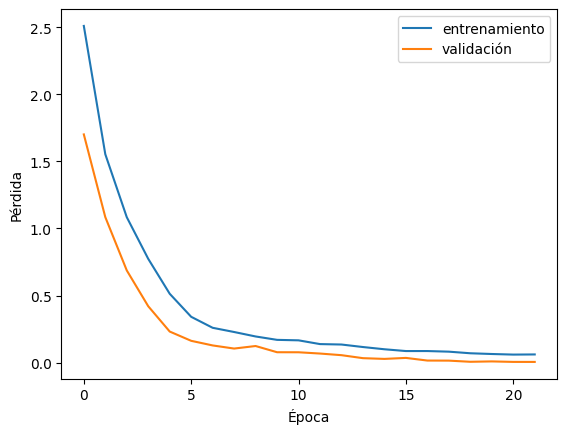

In [11]:
def entrenar_modelo(usar_posicion=True, epocas=22):
    torch.manual_seed(SEMILLA)
    modelo = TraductorTransformer(
        len(vocab_src), len(vocab_tgt), PAD_SRC, PAD_TGT,
        d_modelo=48, cabezas=4, capas=2, d_ff=96,
        dropout=0.1, usar_posicion=usar_posicion,
    ).to(DISPOSITIVO)
    criterio = nn.CrossEntropyLoss(ignore_index=PAD_TGT)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=2e-3)
    historia = {"train": [], "val": []}
    mejor_estado = None
    mejor_val = float("inf")

    for epoca in range(1, epocas + 1):
        perdida_train = ejecutar_epoca(modelo, dl_entrenamiento, criterio, optimizador)
        perdida_val = ejecutar_epoca(modelo, dl_validacion, criterio)
        historia["train"].append(perdida_train)
        historia["val"].append(perdida_val)
        if perdida_val < mejor_val:
            mejor_val = perdida_val
            mejor_estado = {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}
        if epoca == 1 or epoca % 5 == 0 or epoca == epocas:
            print(f"época {epoca:02d} | train {perdida_train:.4f} | val {perdida_val:.4f}")

    modelo.load_state_dict(mejor_estado)
    return modelo, historia


modelo, historia = entrenar_modelo(usar_posicion=True)
assert len(historia["train"]) == 22
assert historia["train"][-1] < historia["train"][0]
print("OK - entrenamiento completado")

plt.plot(historia["train"], label="entrenamiento")
plt.plot(historia["val"], label="validación")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.show()

# Ejemplos de funciones utilizadas en este bloque:
# nn.CrossEntropyLoss(...), torch.optim.Adam(...), model.state_dict()
# Tensor.detach().cpu().clone(), plt.plot(...)

## Bloque 5 - Traducir palabra por palabra (10 puntos)

Empiece el decoder con `<SOS>`. En cada paso agregue la palabra con mayor logit y deténgase al producir
`<EOS>` o alcanzar el largo máximo.

In [12]:
@torch.no_grad()
def traducir(modelo, frase_secreta, max_largo=16):
    # TODO: codifique la frase y agregue dimensión de batch.
    # TODO: inicie la salida con <SOS>.
    # TODO: en cada paso llame al modelo, seleccione argmax y deténgase con <EOS>.
    # TODO: convierta los índices generados de vuelta a texto.
    # Ejemplos de funciones que puede utilizar:
    # vocab_src.codificar(...), torch.tensor(..., device=DISPOSITIVO)
    # logits[0, -1].argmax().item(), list.append(...), vocab_tgt.decodificar(...)
    
    modelo.eval()

    # Codificar la frase de entrada y agregar dimensión de batch.
    src = vocab_src.codificar(frase_secreta)
    src = torch.tensor(src, dtype=torch.long, device=DISPOSITIVO).unsqueeze(0)

    # Índices de tokens especiales.
    sos = vocab_tgt.token_a_id["<SOS>"]
    eos = vocab_tgt.token_a_id["<EOS>"]

    # Iniciar decoder con <SOS>.
    generados = [sos]

    for _ in range(max_largo - 1):
        tgt = torch.tensor(generados, dtype=torch.long, device=DISPOSITIVO).unsqueeze(0)
        logits = modelo(src, tgt)

        # Seleccionar la palabra con mayor logit.
        siguiente = logits[0, -1].argmax().item()
        generados.append(siguiente)

        # Detenerse si genera <EOS>.
        if siguiente == eos:
            break

    return vocab_tgt.decodificar(generados)

In [13]:
def evaluar_traducciones(modelo, pares, limite=None):
    seleccion = pares if limite is None else pares[:limite]
    tokens_correctos = 0
    tokens_totales = 0
    frases_exactas = 0
    for fila in seleccion:
        pred = traducir(modelo, fila["idioma_secreto"])
        real = fila["espanol"]
        frases_exactas += int(pred == real)
        pred_tokens, real_tokens = pred.split(), real.split()
        largo = max(len(pred_tokens), len(real_tokens))
        tokens_correctos += sum(
            i < len(pred_tokens) and i < len(real_tokens) and pred_tokens[i] == real_tokens[i]
            for i in range(largo)
        )
        tokens_totales += largo
    return {
        "exactitud_tokens": tokens_correctos / tokens_totales,
        "frases_exactas": frases_exactas / len(seleccion),
    }


metricas = evaluar_traducciones(modelo, pares_validacion)
print(metricas)
for fila in pares_validacion[:5]:
    print("secreto :", fila["idioma_secreto"])
    print("esperado:", fila["espanol"])
    print("modelo  :", traducir(modelo, fila["idioma_secreto"]), "\n")

assert 0.0 <= metricas["exactitud_tokens"] <= 1.0
assert metricas["exactitud_tokens"] >= 0.70, "El traductor todavía necesita entrenamiento o correcciones."
print("OK - traductor funcional")

# Ejemplos de funciones utilizadas en este bloque:
# traducir(...), str.split(), max(...), sum(...)

{'exactitud_tokens': 1.0, 'frases_exactas': 1.0}
secreto : ribi kita ribi bene tore mibe
esperado: el músico cuida el jardinero azul
modelo  : el músico cuida el jardinero azul 

secreto : ribi kita vivi kote mivi tole
esperado: el músico mira la médica verde
modelo  : el músico mira la médica verde 

secreto : ribi zoli ribi toge kita tole
esperado: el perro mira el músico feliz
modelo  : el perro mira el músico feliz 

secreto : ribi rori vivi sivi taki liba
esperado: el niño lee la niña grande
modelo  : el niño lee la niña grande 

secreto : vivi gore vivi kote taki giki zova
esperado: la maestra no lleva la niña verde
modelo  : la maestra no lleva la niña verde 

OK - traductor funcional


## Bloque 6 - Reto de investigación aplicado (5 puntos)

Entrene una segunda configuración con `usar_posicion=False`. Registre la pérdida de validación, la
exactitud por token y el porcentaje de frases exactas de ambos modelos. Escriba un párrafo que compare
el resultado con la predicción presentada en la respuesta 3 del Bloque 0.

La comparación debe usar los mismos datos, semilla, arquitectura y cantidad de épocas. No se califica
que la diferencia tenga una dirección específica; se califica que la comparación sea justa y que la
conclusión coincida con la evidencia.

In [14]:
modelo_sin_posicion, historia_sin_posicion = entrenar_modelo(usar_posicion=False)
metricas_sin_posicion = evaluar_traducciones(modelo_sin_posicion, pares_validacion)

resultados = {
    "con_posicion": metricas,
    "sin_posicion": metricas_sin_posicion,
}
print(resultados)

# Ejemplos de funciones utilizadas en este bloque:
# entrenar_modelo(usar_posicion=False), evaluar_traducciones(...), print(...)

época 01 | train 2.3558 | val 1.5552
época 05 | train 0.2869 | val 0.1677
época 10 | train 0.1405 | val 0.1155
época 15 | train 0.1330 | val 0.1059
época 20 | train 0.1195 | val 0.1094
época 22 | train 0.1178 | val 0.1080
{'con_posicion': {'exactitud_tokens': 1.0, 'frases_exactas': 1.0}, 'sin_posicion': {'exactitud_tokens': 0.758575197889182, 'frases_exactas': 0.49166666666666664}}


### Comparación y conclusión

Escriba aquí un párrafo breve que describa los resultados, los conecte con su predicción y señale al
menos una limitación del experimento.  

La pérdida de la posición generó una disminusión en la exactitud de los tokens y de las frases. Esto coincide con lo esperado, ya que la atención por sí sola no representa explícitamente el orden de las palabras. El modelo todavía puede apredender asociación entre tokens, pero es más complicado.  
Una limitación de este experimento es que solo se ejecutó una vez, por lo que los resultados pueden variar debido a la aleatoriedad inicial en el etrenamiento.

## Bloque 7 - Entrega y concurso (5 puntos)

Pegue las frases secretas proporcionadas por el profesor en la lista siguiente. Ejecute la celda para
producir las traducciones que se usarán en la prueba oculta y en el concurso.

In [15]:
frases_del_reto = [
    # "pegue aquí la primera frase secreta",
    # "pegue aquí la segunda frase secreta",
    # "pegue aquí la tercera frase secreta",
]

traducciones_del_reto = [traducir(modelo, frase) for frase in frases_del_reto]
for frase, traduccion in zip(frases_del_reto, traducciones_del_reto):
    print(frase, "->", traduccion)

# Ejemplos de funciones utilizadas en este bloque:
# traducir(...), zip(...), print(...)

### Registro de contribuciones

| Integrante | Investigación y aportes concretos |
|---|---|
| Ian Castellanos | Aportó en la investigación y realizó del bloque 1 al 4|
| Ricardo Rodríguez | Aportó en la investigación y realizó el bloque 5 y 6 |

Antes de entregar: reinicie el kernel, ejecute todo, confirme los mensajes `OK`, guarde las salidas y
conserve el nombre solicitado. Cada integrante debe poder explicar cualquier bloque del notebook.